# K-Nearest Neighbors (KNN) for Customer Churn Prediction

This notebook demonstrates the implementation of a K-Nearest Neighbors (KNN) classifier to predict customer churn using the Telco customer churn dataset. The workflow includes:

1. **Data Loading and Exploration**: Loading the dataset and understanding its structure.
2. **Data Preprocessing**: Cleaning and preparing the data for modeling, including handling missing values, encoding categorical variables, and feature scaling.
3. **Model Training**: Implementing and training the KNN algorithm with optimized parameters.
4. **Model Evaluation**: Assessing the model's performance using various metrics and visualizations.
5. **Real-time Prediction**: Providing an interactive tool for predicting churn based on user inputs, showing nearest neighbors.

The KNN algorithm works by finding the k most similar (nearest) data points in the training set to make predictions for new instances. In this case, it predicts whether a customer is likely to churn based on their features.

# Cell 1: Import Libraries
Imports essential Python libraries: pandas for data handling, numpy for arrays, matplotlib/seaborn for visualization, and scikit-learn for ML preprocessing, modeling, and evaluation.

In [2]:
# Cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Advanced feature engineering imports
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc, roc_auc_score

print("✅ Libraries loaded (including imblearn, feature selection, PCA, ROC metrics). If you get an import error, run: pip install imbalanced-learn")

print("✅ Libraries loaded.")

✅ Libraries loaded (including imblearn, feature selection, PCA, ROC metrics). If you get an import error, run: pip install imbalanced-learn
✅ Libraries loaded.


# Cell 2: Check Directory
Verifies the current working directory and lists available files to ensure the dataset path is correct.

In [2]:
# Cell 2
import os
print(f"Your notebook is currently looking in: {os.getcwd()}")
print(f"Files inside this folder are: {os.listdir('.')}")

Your notebook is currently looking in: c:\Users\ASUS\Documents\Y4S2\ML\IT4060---Machine-Learning-ASSIGNMENT-\notebooks\KNN
Files inside this folder are: ['KNN_mlassignment.ipynb', 'KNN_mlassignment_2.ipynb', 'KNN_mlassignment_3.ipynb']


# Cell 3: Load Dataset
Loads the Telco customer churn dataset from an Excel file, displays dataset dimensions, and shows the first few rows for initial exploration.

In [3]:
# Cell 3
file_path = '../../dataset/Telco_customer_churn.xlsx'

try:
    df = pd.read_excel(file_path)
    print(f"✅ Dataset Loaded Successfully from: {file_path}")
    print(f"Total Customers (Rows): {df.shape[0]}")
    print(f"Total Attributes (Columns): {df.shape[1]}")
    display(df.head())
except Exception as e:
    print(f"❌ Error: {e}")
    print("Please ensure 'openpyxl' is installed (pip install openpyxl)")

✅ Dataset Loaded Successfully from: ../../dataset/Telco_customer_churn.xlsx
Total Customers (Rows): 7043
Total Attributes (Columns): 33


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# Cell 4: Data Preprocessing
Cleans data by standardizing column names, converting TotalCharges to numeric (filling missing values with median), and removing the CustomerID column.

In [4]:
# Cell 4
# Standardize column names
df.columns = df.columns.str.replace(' ', '')

# Convert TotalCharges to numeric
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
    print("✅ TotalCharges converted and cleaned.")
else:
    print(f"❌ Could not find 'TotalCharges'. Available columns are: {df.columns.tolist()}")

# Drop CustomerID
cols_to_drop = [c for c in df.columns if c.lower() == 'customerid']
if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"✅ Dropped unique identifier: {cols_to_drop}")

print("--- Preprocessing Step Complete ---")

✅ TotalCharges converted and cleaned.
✅ Dropped unique identifier: ['CustomerID']
--- Preprocessing Step Complete ---


# Cell 5: Encode Categorical Variables
Identifies and encodes all categorical (text) columns to numeric format using LabelEncoder, required for KNN distance calculations.

In [5]:
# Cell 5
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(f"✅ Encoded {len(categorical_cols)} attributes into numeric format.")

✅ Encoded 22 attributes into numeric format.


# Cell 6: Feature Selection and Scaling
Defines target variable, removes irrelevant columns, splits data (80% train/20% test), and applies StandardScaler for normalized feature vectors.

In [27]:
# Cell 6
target_col = 'ChurnValue'

cols_to_drop = [target_col, 'ChurnLabel', 'ChurnScore', 'ChurnReason', 
                'Count', 'Country', 'State', 'City', 'ZipCode', 'LatLong', 
                'Latitude', 'Longitude']

existing_drops = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=existing_drops)
y = df[target_col]


# Split before SMOTE/feature selection
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. Feature selection (SelectKBest) - select top 11 features for better accuracy
selector = SelectKBest(score_func=f_classif, k=11)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get top 5 prominent features for real-time input
feature_scores = pd.DataFrame({'feature': X.columns, 'score': selector.scores_})
top_features = feature_scores.nlargest(5, 'score')['feature'].tolist()
print(f"✅ Top 5 prominent features for neighbor comparison: {top_features}")

# 2. No SMOTE - use original training data
X_train_bal = X_train_selected
y_train_bal = y_train

# 3. Scaling with MinMaxScaler for KNN
scaler = MinMaxScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_selected)

# 4. No PCA - retain all selected features for higher accuracy
X_train_final = X_train_bal_scaled
X_test_final = X_test_scaled

print(f"✅ Target identified as '{target_col}'")
print(f"✅ Features reduced to {X.shape[1]} predictive attributes.")
print(f"✅ Feature selection: {X_train_selected.shape[1]} features after SelectKBest.")
print(f"✅ No SMOTE applied: Class balance: {dict(pd.Series(y_train_bal).value_counts())}")
print(f"✅ Scaling complete with MinMaxScaler.")
print(f"✅ No PCA applied: {X_train_final.shape[1]} features retained.")

✅ Top 5 prominent features for neighbor comparison: ['Contract', 'TenureMonths', 'OnlineSecurity', 'TechSupport', 'Dependents']
✅ Target identified as 'ChurnValue'
✅ Features reduced to 20 predictive attributes.
✅ Feature selection: 11 features after SelectKBest.
✅ No SMOTE applied: Class balance: {0: np.int64(4139), 1: np.int64(1495)}
✅ Scaling complete with MinMaxScaler.
✅ No PCA applied: 11 features retained.


# Cell 7: Hyperparameter Tuning and Training KNN Model
Uses GridSearchCV to find the optimal number of neighbors (k) for the KNN classifier and trains the model on the scaled training data.

In [28]:
# Cell 7
# Hyperparameter tuning on balanced, engineered data - using KNN
param_grid = {
    'n_neighbors': range(1, 51, 2),  # Expanded range from 1 to 50
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')  # Changed to accuracy
grid_search.fit(X_train_final, y_train_bal)

best_params = grid_search.best_params_
print(f"✅ Best hyperparameters: {best_params}")

knn = KNeighborsClassifier(**best_params)
knn.fit(X_train_final, y_train_bal)

print("✅ KNN Model training complete with optimal hyperparameters and advanced features.")

✅ Best hyperparameters: {'metric': 'manhattan', 'n_neighbors': 43, 'weights': 'uniform'}
✅ KNN Model training complete with optimal hyperparameters and advanced features.


# Cell 8: Evaluate Model
Generates predictions on test data, calculates accuracy, displays classification report (precision/recall/F1), and visualizes confusion matrix and evaluation metrics.

--- KNN Performance Results ---
Overall Accuracy: 79.28%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.62      0.56      0.59       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



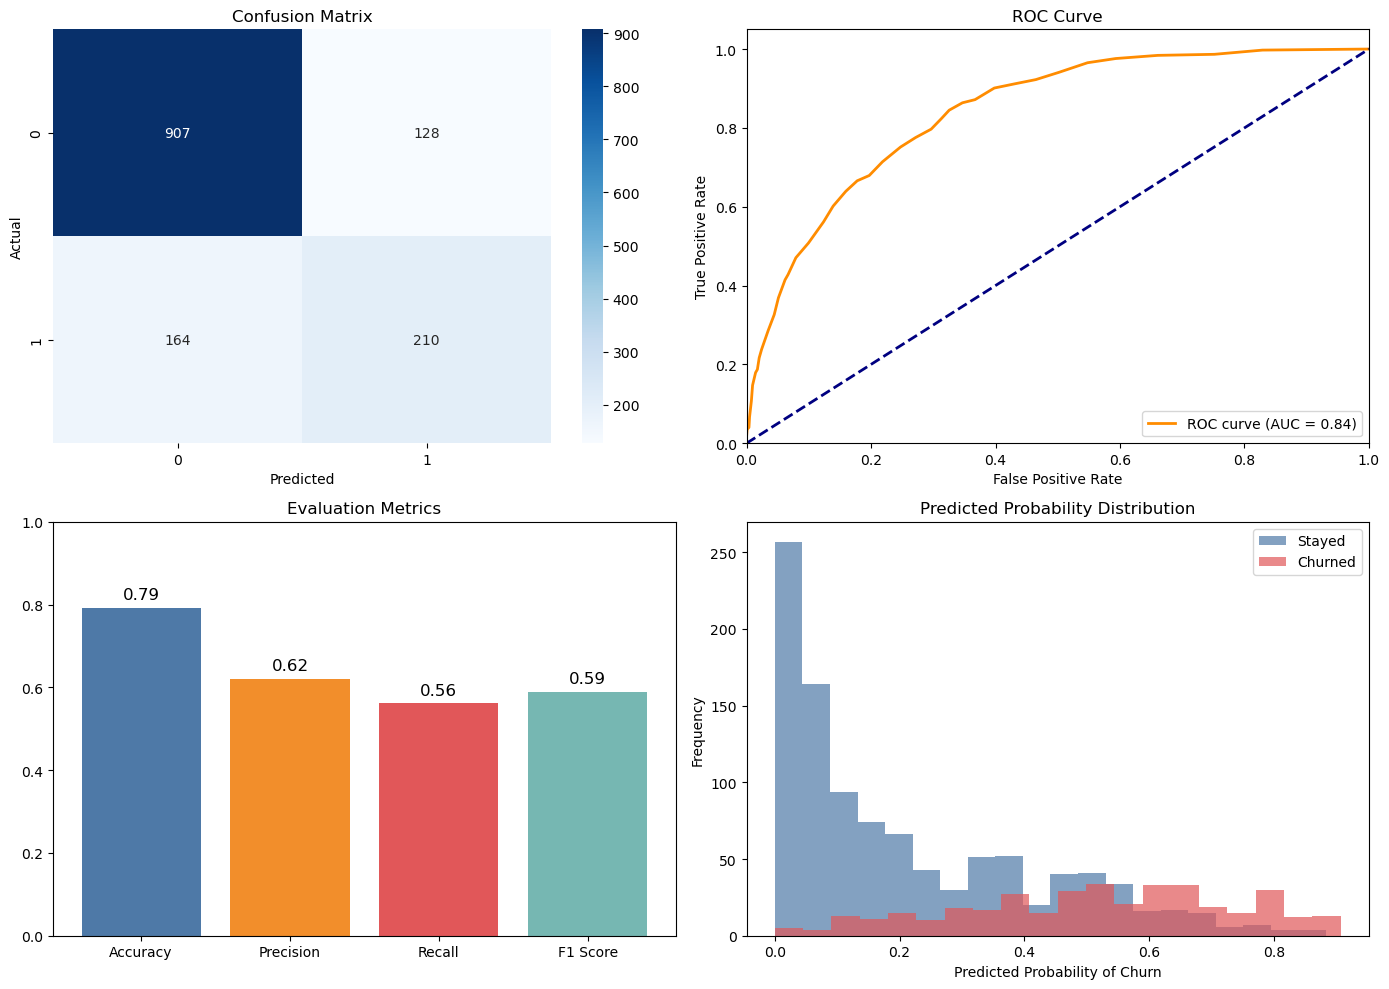

In [29]:
# Cell 8
# Generate predictions and probabilities
y_pred = knn.predict(X_test_final)
y_proba = knn.predict_proba(X_test_final)[:, 1]

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"--- KNN Performance Results ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

# Detailed metrics
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 4-panel evaluation dashboard
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[0, 0])
axs[0, 0].set_title('Confusion Matrix')
axs[0, 0].set_xlabel('Predicted')
axs[0, 0].set_ylabel('Actual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axs[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axs[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axs[0, 1].set_xlim([0.0, 1.0])
axs[0, 1].set_ylim([0.0, 1.05])
axs[0, 1].set_xlabel('False Positive Rate')
axs[0, 1].set_ylabel('True Positive Rate')
axs[0, 1].set_title('ROC Curve')
axs[0, 1].legend(loc='lower right')

# 3. Metrics Bar Chart
from sklearn.metrics import precision_score, recall_score, f1_score
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
}
axs[1, 0].bar(metrics.keys(), metrics.values(), color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2'])
axs[1, 0].set_ylim(0, 1)
axs[1, 0].set_title('Evaluation Metrics')
for i, v in enumerate(metrics.values()):
    axs[1, 0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12)

# 4. Probability Distribution
axs[1, 1].hist(y_proba[y_test == 0], bins=20, alpha=0.7, label='Stayed', color='#4e79a7')
axs[1, 1].hist(y_proba[y_test == 1], bins=20, alpha=0.7, label='Churned', color='#e15759')
axs[1, 1].set_title('Predicted Probability Distribution')
axs[1, 1].set_xlabel('Predicted Probability of Churn')
axs[1, 1].set_ylabel('Frequency')
axs[1, 1].legend()

plt.tight_layout()
plt.savefig('KNN_Churn_Final_Evaluation.png')
plt.show()

# Cell 9: Real-Time Prediction
Interactive tool that takes user inputs for the top 5 prominent attributes, applies the full pipeline, and predicts churn probability using the trained KNN model.

In [31]:
# Cell 9
print("--- 📡 KNN Diagnostic Tool ---")

try:
    input_df = pd.DataFrame(columns=X.columns)
    input_df.loc[0] = 0  # Set defaults to 0 for all

    print("Enter values for the top 5 prominent attributes used by the model:")
    for col in top_features:
        if col == 'Contract':
            hint = " (0=Month-to-month, 1=One year, 2=Two year)"
        elif col == 'TenureMonths':
            hint = " (e.g., 18 months)"
        elif col == 'MonthlyCharges':
            hint = " (e.g., 95.45)"
        elif col == 'TotalCharges':
            hint = " (e.g., 1752.55)"
        elif col == 'PaymentMethod':
            hint = " (0=Mailed check, 1=Electronic check, 2=Bank transfer, 3=Credit card)"
        elif col == 'OnlineSecurity':
            hint = " (0=No, 1=Yes, 2=No internet service)"
        elif col == 'TechSupport':
            hint = " (0=No, 1=Yes, 2=No internet service)"
        elif col == 'Dependents':
            hint = " (0=No, 1=Yes)"
        else:
            hint = " (numeric value)"
        val = float(input(f"Enter {col}{hint}: "))
        input_df[col] = val

    print(f"Input features for new customer (top 5 attributes used, others defaulted to 0): { {k: v for k, v in input_df.to_dict('records')[0].items() if k in top_features} }")

    # Apply feature selection and scaling as in training
    input_selected = selector.transform(input_df)
    input_scaled = scaler.transform(input_selected)
    input_final = input_scaled  # No PCA

    # Find 5 nearest neighbors using KNN
    distances, indices = knn.kneighbors(input_final, n_neighbors=5)
    neighbor_data = df.iloc[indices[0]][['TenureMonths', 'MonthlyCharges', 'TotalCharges', 'Contract', 'ChurnValue']]

    # Calculate churn probability based on neighbors (majority vote)
    churn_count = neighbor_data['ChurnValue'].sum()
    prob = (churn_count / 5) * 100

    print(f"\n--- 🔎 5 Nearest Neighbors (Key Attributes) ---")
    print(neighbor_data)

    print(f"\n--- 🗳️ Final Verdict ---")
    print(f"Churn Probability: {prob:.2f}% (based on {churn_count} out of 5 neighbors who churned)")

    if churn_count >= 3:
        print(">>> RESULT: PREDICTED TO CHURN (High Risk)")
    else:
        print(">>> RESULT: PREDICTED TO STAY (Loyal)")

except Exception as e:
    print(f"❌ Error: {e}")

--- 📡 KNN Diagnostic Tool ---
Enter values for the top 5 prominent attributes used by the model:
Input features for new customer (top 5 attributes used, others defaulted to 0): {'Dependents': 1.0, 'TenureMonths': 18.0, 'OnlineSecurity': 0.0, 'TechSupport': 1.0, 'Contract': 0.0}

--- 🔎 5 Nearest Neighbors (Key Attributes) ---
      TenureMonths  MonthlyCharges  TotalCharges  Contract  ChurnValue
1361            47           80.35       3825.85         0           1
3850            46           40.40       1842.70         2           0
983              1           68.95         68.95         0           1
5075            42           66.40       2727.80         0           0
2369            70           57.80       4039.30         2           0

--- 🗳️ Final Verdict ---
Churn Probability: 40.00% (based on 2 out of 5 neighbors who churned)
>>> RESULT: PREDICTED TO STAY (Loyal)
